In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

df_dev = pd.read_csv('../data/base_pagamentos_desenvolvimento.csv', sep=';')
df_cad = pd.read_csv('../data/base_cadastral.csv', sep=';')
df_info = pd.read_csv('../data/base_info.csv', sep=';')


df_dev = df_dev.dropna(subset=['DATA_PAGAMENTO']).copy()
df_dev['DATA_VENCIMENTO'] = pd.to_datetime(df_dev['DATA_VENCIMENTO'])
df_dev['DATA_PAGAMENTO'] = pd.to_datetime(df_dev['DATA_PAGAMENTO'])
df_dev['DIAS_ATRASO'] = (df_dev['DATA_PAGAMENTO'] - df_dev['DATA_VENCIMENTO']).dt.days
df_dev['INADIMPLENTE'] = (df_dev['DIAS_ATRASO'] >= 5).astype(int)
df_dev['SAFRA_REF'] = pd.to_datetime(df_dev['SAFRA_REF'], format='%Y-%m')

df_cad[['PORTE', 'SEGMENTO_INDUSTRIAL']] = df_cad[['PORTE', 'SEGMENTO_INDUSTRIAL']].fillna('Outros')
regioes_ddd = {
    "Norte": ["63", "68", "69", "91", "92", "93", "94", "95", "96", "97"],
    "Nordeste": ["71", "73", "74", "75", "77", "79", "81", "82", "83", "84", "85", "86", "87", "88", "89", "98", "99"],
    "Centro-Oeste": ["61", "62", "64", "65", "66", "67"],
    "Sudeste": ["11", "12", "13", "14", "15", "16", "17", "18", "19", "21", "22", "24", "27", "28", "31", "32", "33", "34", "35", "37", "38"],
    "Sul": ["41", "42", "43", "44", "45", "46", "47", "48", "49", "51", "53", "54", "55"]
}
ddd_to_regiao = {ddd: regiao for regiao, ddds in regioes_ddd.items() for ddd in ddds}
df_cad['REGIAO'] = df_cad['DDD'].map(ddd_to_regiao).fillna('Desconhecido')

df_eda = df_dev.merge(df_cad, on='ID_CLIENTE', how='left')
df_info['SAFRA_REF'] = pd.to_datetime(df_info['SAFRA_REF'], format='%Y-%m')
df_eda = df_eda.merge(df_info, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')

Carregando bases brutas para EDA...


In [12]:
df_eda.head(50)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DIAS_ATRASO,INADIMPLENTE,DATA_CADASTRO,...,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,REGIAO,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,VALOR_LOG,RENDA_LOG,TIPO_CLIENTE
0,1661240395903230676,2018-08-01,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,0,0,2013-08-22,...,Serviços,YAHOO,PEQUENO,65,Nordeste,NaN,NaN,10.477778,NaN,Empresa (PJ)
1,1661240395903230676,2018-08-01,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,1,0,2013-08-22,...,Serviços,YAHOO,PEQUENO,65,Nordeste,NaN,NaN,9.784660,NaN,Empresa (PJ)
2,1661240395903230676,2018-08-01,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,1,0,2013-08-22,...,Serviços,YAHOO,PEQUENO,65,Nordeste,NaN,NaN,9.766118,NaN,Empresa (PJ)
3,1661240395903230676,2018-08-01,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,6,1,2013-08-22,...,Serviços,YAHOO,PEQUENO,65,Nordeste,NaN,NaN,7.201916,NaN,Empresa (PJ)
4,1661240395903230676,2018-08-01,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,0,0,2013-08-22,...,Serviços,YAHOO,PEQUENO,65,Nordeste,NaN,NaN,9.966972,NaN,Empresa (PJ)
5,8274986328479596038,2018-08-01,2018-08-17,2018-09-25,2018-09-25,48811.35,6.99,0,0,2017-01-25,...,Comércio,YAHOO,MEDIO,77,Sudeste,NaN,NaN,10.795739,NaN,Empresa (PJ)
6,345447888460137901,2018-08-01,2018-08-17,2018-09-05,2018-09-05,55131.20,5.99,0,0,2000-08-15,...,Serviços,HOTMAIL,PEQUENO,48,Nordeste,NaN,NaN,10.917489,NaN,Empresa (PJ)
7,1003144834589372198,2018-08-01,2018-08-17,2018-09-03,2018-09-03,85855.04,6.99,0,0,2017-08-06,...,Serviços,OUTLOOK,PEQUENO,89,Sul,NaN,NaN,11.360427,NaN,Empresa (PJ)
8,324916756972236008,2018-08-01,2018-08-17,2018-09-03,2018-09-03,42072.00,5.99,0,0,2011-02-14,...,Serviços,GMAIL,GRANDE,62,Nordeste,NaN,NaN,10.647161,NaN,Empresa (PJ)
9,324916756972236008,2018-08-01,2018-08-19,2018-09-05,2018-09-05,21071.97,5.99,0,0,2011-02-14,...,Serviços,GMAIL,GRANDE,62,Nordeste,NaN,NaN,9.955746,NaN,Empresa (PJ)


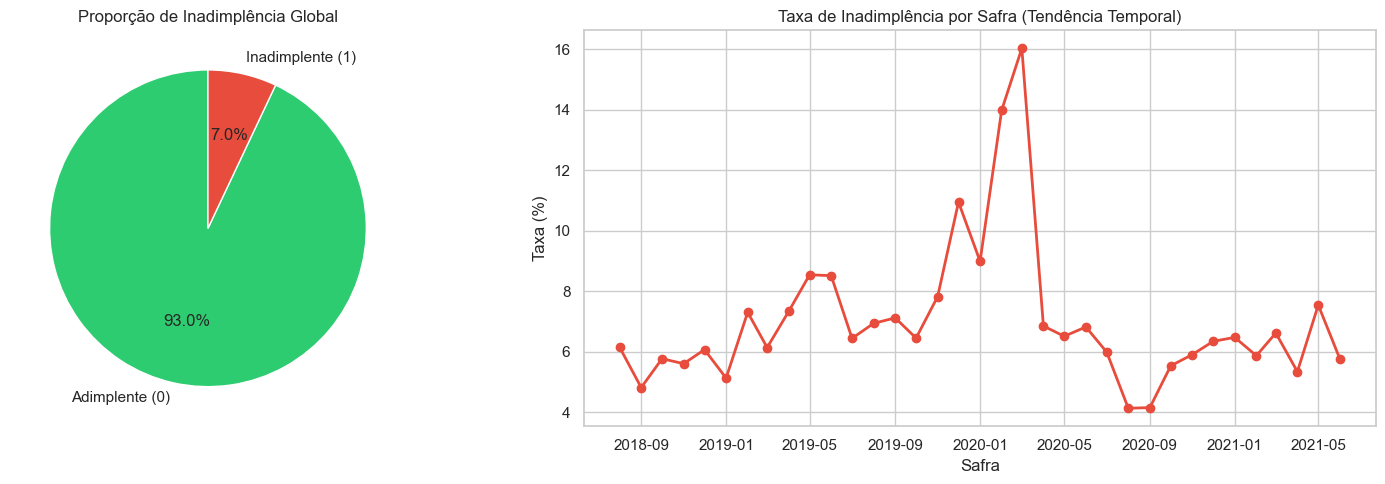

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#Proporção de Inadimplência
tx_inadimplencia = df_eda['INADIMPLENTE'].value_counts(normalize=True) * 100
axes[0].pie(tx_inadimplencia, labels=['Adimplente (0)', 'Inadimplente (1)'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Proporção de Inadimplência Global')

# Inadimplência ao longo do tempo (Safra)
taxa_tempo = df_eda.groupby('SAFRA_REF')['INADIMPLENTE'].mean() * 100
axes[1].plot(taxa_tempo.index, taxa_tempo.values, marker='o', color='#e74c3c', linewidth=2)
axes[1].set_title('Taxa de Inadimplência por Safra (Tendência Temporal)')
axes[1].set_ylabel('Taxa (%)')
axes[1].set_xlabel('Safra')
axes[1].grid(True)
plt.tight_layout()
plt.show()

C:\Users\mifer\AppData\Local\Temp\ipykernel_17488\2998217499.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='INADIMPLENTE', y='VALOR_LOG', data=df_eda, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\mifer\AppData\Local\Temp\ipykernel_17488\2998217499.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Pagou em dia', 'Atrasou'])
C:\Users\mifer\AppData\Local\Temp\ipykernel_17488\2998217499.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='INADIMPLENTE', y='RENDA_LOG', data=df_eda, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
C:\Users\mifer\AppData\Local\Temp\ipyker

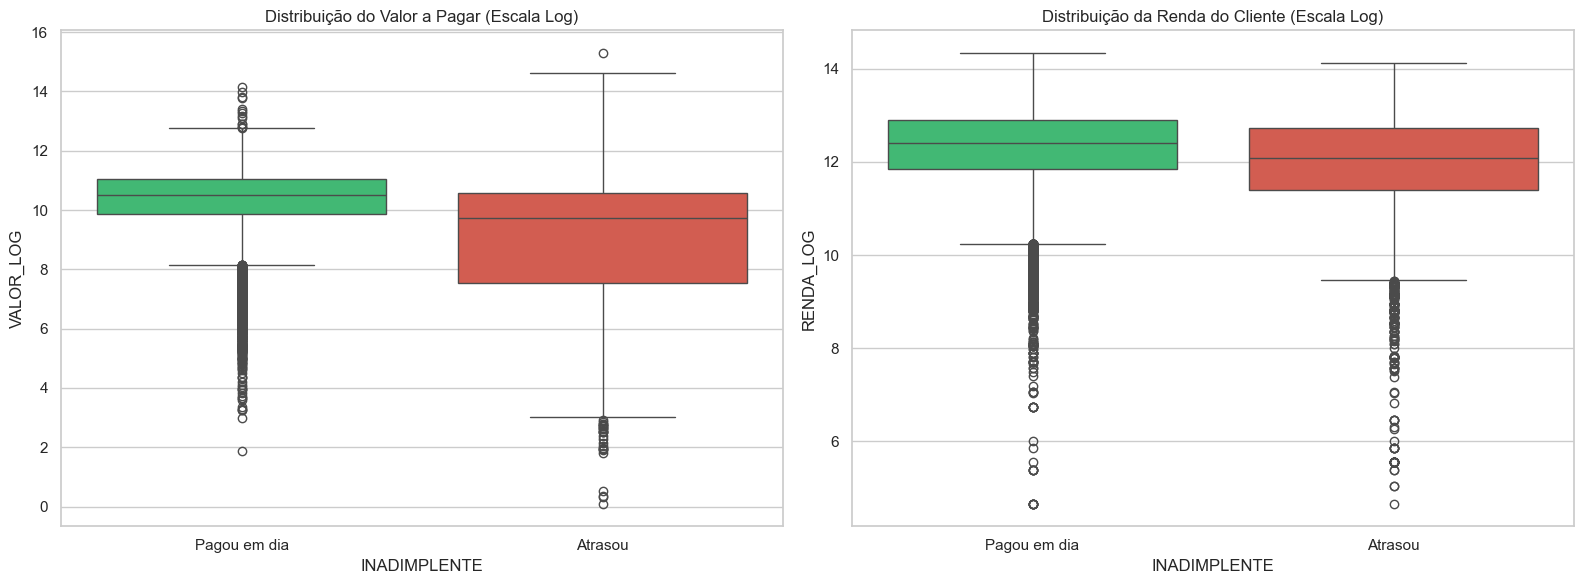

In [ ]:
# Comportamento Financeiro
# Usamos log1p (log + 1) para visualizar melhor porque valores financeiros costumam ter outliers absurdos
df_eda['VALOR_LOG'] = np.log1p(df_eda['VALOR_A_PAGAR'])
df_eda['RENDA_LOG'] = np.log1p(df_eda['RENDA_MES_ANTERIOR'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='INADIMPLENTE', y='VALOR_LOG', data=df_eda, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição do Valor a Pagar (Escala Log)')
axes[0].set_xticklabels(['Pagou em dia', 'Atrasou'])

sns.boxplot(x='INADIMPLENTE', y='RENDA_LOG', data=df_eda, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribuição da Renda do Cliente (Escala Log)')
axes[1].set_xticklabels(['Pagou em dia', 'Atrasou'])
plt.tight_layout()
plt.show()

C:\Users\mifer\AppData\Local\Temp\ipykernel_17488\2163633875.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agrupado['mean'], y=agrupado.index, ax=ax, palette='Reds_r')
C:\Users\mifer\AppData\Local\Temp\ipykernel_17488\2163633875.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agrupado['mean'], y=agrupado.index, ax=ax, palette='Reds_r')
C:\Users\mifer\AppData\Local\Temp\ipykernel_17488\2163633875.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agrupado['mean'], y=agrupado.index, ax=ax, palette='Reds_r')


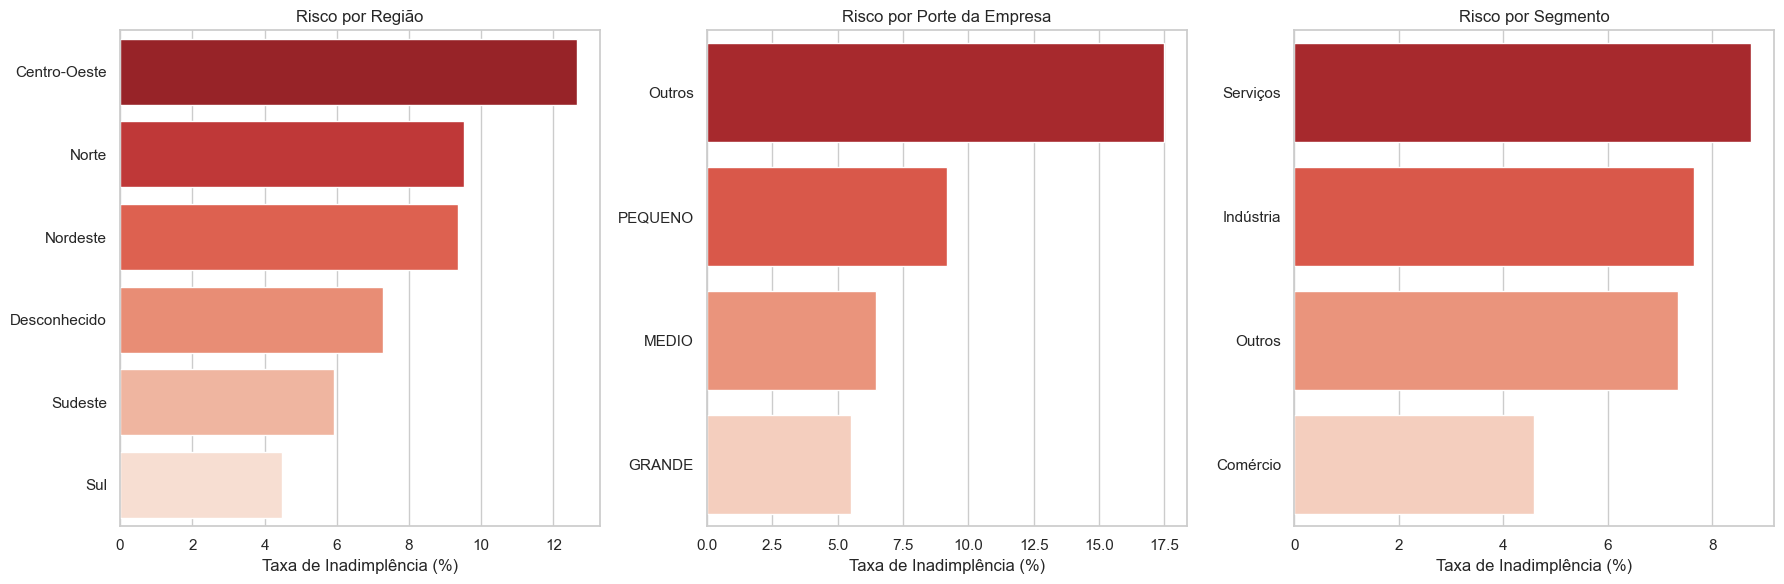

In [ ]:
#  Taxa de Inadimplência por Variáveis Cadastrais
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Função auxiliar para plotar a taxa
def plot_taxa(df, coluna, ax, titulo):
    agrupado = df.groupby(coluna)['INADIMPLENTE'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
    agrupado['mean'] = agrupado['mean'] * 100 
    # Filtra categorias com volume muito baixo para não sujar o gráfico
    agrupado = agrupado[agrupado['count'] > 100] 
    
    sns.barplot(x=agrupado['mean'], y=agrupado.index, ax=ax, palette='Reds_r')
    ax.set_title(titulo)
    ax.set_xlabel('Taxa de Inadimplência (%)')
    ax.set_ylabel('')

plot_taxa(df_eda, 'REGIAO', axes[0], 'Risco por Região')
plot_taxa(df_eda, 'PORTE', axes[1], 'Risco por Porte da Empresa')
plot_taxa(df_eda, 'SEGMENTO_INDUSTRIAL', axes[2], 'Risco por Segmento')

plt.tight_layout()
plt.show()

In [10]:
# Mapeia o 'X' original para PF e os nulos para PJ
df_eda['TIPO_CLIENTE'] = df_eda['FLAG_PF'].map({'X': 'Pessoa Física (PF)'}).fillna('Empresa (PJ)')

# Faz o cruzamento
cruzamento_pf_porte = pd.crosstab(
    df_eda['PORTE'], 
    df_eda['TIPO_CLIENTE']
)

print(cruzamento_pf_porte)

TIPO_CLIENTE  Empresa (PJ)  Pessoa Física (PF)
PORTE                                         
GRANDE               28955                  77
MEDIO                29861                  68
Outros                2475                   1
PEQUENO              15904                  73


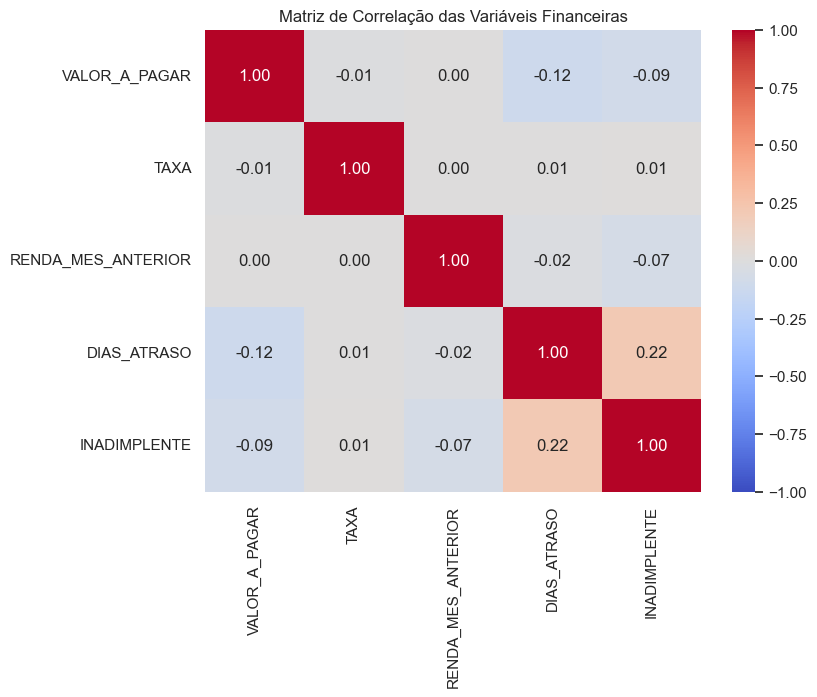

In [ ]:

plt.figure(figsize=(8, 6))
cols_corr = ['VALOR_A_PAGAR', 'TAXA', 'RENDA_MES_ANTERIOR', 'DIAS_ATRASO', 'INADIMPLENTE']
sns.heatmap(df_eda[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação das Variáveis Financeiras')
plt.show()